In [13]:
from tensorflow import keras
import numpy as np
from matplotlib import pyplot as plt

In [14]:
# load dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

In [15]:
x_train = x_train.astype(float) / 255.
x_test  = x_test.astype(float) / 255.

In [16]:
# Convert class vectors to binary class matrices.
num_classes = 10
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)

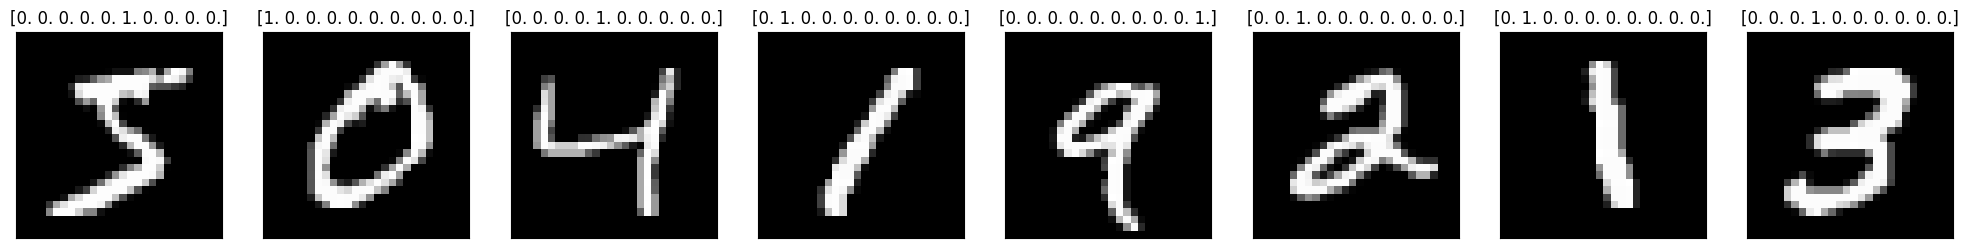

In [17]:
# show dataset
plt.figure(figsize=(25,4))
for i in range(8):
  plt.subplot(1,8,i+1)
  plt.imshow(x_train[i], cmap='gray')
  plt.xticks([])
  plt.yticks([])
  plt.title(str(y_train[i]))

In [18]:
# define model
model = keras.Sequential()
model.add(keras.layers.Input(shape=x_train[0].shape))
model.add(keras.layers.Flatten())
model.add(keras.layers.Dense(units=512, activation='relu'))
model.add(keras.layers.Dense(units=10, activation='sigmoid'))

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 407,050 (1.55 MB)

 Trainable params: 407,050 (1.55 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
# compile model
model.compile(loss='mse', optimizer='adam')

# train model
history = model.fit(x_train, y_train,
                    validation_data=(x_test, y_test),
                    batch_size=100,
                    epochs=10,
                    verbose=0,
                    shuffle=True)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
[0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
[7.91e-06 4.21e-07 6.38e-06 4.99e-04 4.71e-12 1.01e-06 2.19e-10 1.00e+00 3.42e-06 2.89e-06]


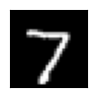

[0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
[1.65e-05 4.43e-06 1.00e+00 6.29e-06 9.50e-14 3.37e-09 3.49e-06 1.05e-15 2.53e-05 7.96e-15]


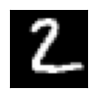

[0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
[3.71e-04 9.91e-01 1.82e-03 6.53e-05 7.65e-04 1.83e-03 2.00e-04 8.11e-04 3.42e-03 7.23e-06]


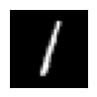

[1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[9.96e-01 2.49e-06 1.38e-05 2.27e-04 2.67e-10 2.87e-06 4.63e-05 1.08e-04 1.40e-11 8.53e-08]


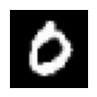

[0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
[9.48e-05 5.28e-06 1.81e-05 1.67e-05 9.92e-01 5.45e-07 3.29e-05 6.48e-05 2.65e-06 4.69e-03]


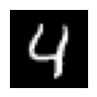

[0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
[3.58e-04 9.99e-01 1.95e-05 2.22e-05 1.95e-04 6.02e-06 3.54e-06 7.12e-03 1.09e-04 1.06e-05]


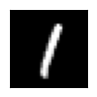

[0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
[3.70e-08 1.21e-05 4.51e-06 2.44e-06 9.99e-01 9.60e-06 6.23e-07 5.96e-05 4.27e-03 9.68e-05]


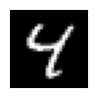

[0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
[5.13e-06 1.18e-05 6.69e-03 3.85e-02 2.04e-04 1.39e-04 2.69e-07 6.55e-05 7.80e-06 9.98e-01]


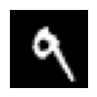

In [20]:
# show results
y_pred = model.predict(x_test)
np.set_printoptions(precision=2, linewidth=200)
for i in range(8):
  print(y_test[i])
  print(y_pred[i])
  plt.figure(figsize=(1, 1))
  plt.imshow(x_test[i], cmap='gray')
  plt.xticks([])
  plt.yticks([])
  plt.show()

In [21]:
accuracy = np.average(np.argmax(y_pred, axis=1) == np.argmax(y_test, axis=1)) * 100
print('accuracy = {} %'.format(accuracy))

accuracy = 98.32 %


In [22]:
import cv2

In [23]:
img = cv2.imread('img2.png', cv2.IMREAD_GRAYSCALE)
img = img / 255.0
img = img.reshape(1, 28, 28)
pred = model.predict(img)
print(np.argmax(pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
2


In [24]:
img = cv2.imread('img1.png', cv2.IMREAD_GRAYSCALE)
img = img / 255.0
img = img.reshape(1, 28, 28)
pred = model.predict(img)
print(np.argmax(pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1


In [25]:
img = cv2.imread('img8.png', cv2.IMREAD_GRAYSCALE)
img = img / 255.0
img = img.reshape(1, 28, 28)
pred = model.predict(img)
print(np.argmax(pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
3


In [26]:
img = cv2.imread('img3png.png', cv2.IMREAD_GRAYSCALE)
img = img / 255.0
img = img.reshape(1, 28, 28)
pred = model.predict(img)
print(np.argmax(pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
3
